# 02 — Phân Tích Dữ Liệu (EDA)
**Input:** `data/processed/student_features_labeled.csv`  
**Mục tiêu:** Hiểu sâu phân phối dữ liệu, phát hiện outlier, phân tích imbalance và tương quan đặc trưng trước khi xây dựng mô hình

---
### Nội dung
1. Load & tổng quan dữ liệu  
2. Phân tích phân phối nhãn (Imbalance)  
3. Phân tích đặc trưng nhân khẩu học  
4. Phân tích hành vi VLE  
5. Phân tích kết quả Assessment  
6. Ma trận tương quan  
7. Phát hiện Outlier  
8. Tổng kết & insight

## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings, os

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.3f}'.format)

PROCESSED_DIR = '../data/processed/'
VISUALS_DIR   = '../visuals/'
os.makedirs(VISUALS_DIR, exist_ok=True)

# Bảng màu thống nhất cho 4 mức rủi ro
RISK_COLORS  = {'Low':'#639922', 'Medium':'#BA7517', 'High':'#D85A30', 'Very High':'#E24B4A'}
RISK_ORDER   = ['Low', 'Medium', 'High', 'Very High']
RISK_PALETTE = [RISK_COLORS[r] for r in RISK_ORDER]

plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11,
    'font.size': 10
})
print('✅ Setup hoàn tất')

✅ Setup hoàn tất


---
## 1. Load & Tổng Quan Dữ Liệu

In [2]:
df = pd.read_csv(PROCESSED_DIR + 'student_features_labeled.csv')

print(f'Shape: {df.shape}')
print(f'Số sinh viên unique: {df["id_student"].nunique():,}')
print(f'Số module: {df["code_module"].nunique()}')
print(f'Số presentation: {df["code_presentation"].nunique()}')
print(f'Missing values: {df.isnull().sum().sum()}')

FEATURE_COLS = [
    'gender_num','imd_band_num','education_num','age_num','disability_num',
    'num_of_prev_attempts','studied_credits',
    'early_registration','reg_days_before','unregistered',
    'total_clicks','active_days','avg_clicks_day','max_clicks_day','n_resources','click_density',
    'avg_score','min_score','std_score','avg_tma_score','n_submitted','n_late','avg_submit_delay'
]

display(df[FEATURE_COLS].describe().T.round(2))

Shape: (32593, 29)
Số sinh viên unique: 28,785
Số module: 7
Số presentation: 4
Missing values: 0


,count,mean,std,min,25%,50%,75%,max
gender_num,32593.000,0.550,0.500,0.000,0.000,1.000,1.000,1.000
imd_band_num,32593.000,5.200,2.770,1.000,3.000,5.000,8.000,10.000
education_num,32593.000,1.740,0.750,0.000,1.000,2.000,2.000,4.000
age_num,32593.000,0.300,0.470,0.000,0.000,0.000,1.000,2.000
disability_num,32593.000,0.100,0.300,0.000,0.000,0.000,0.000,1.000
num_of_prev_attempts,32593.000,0.160,0.480,0.000,0.000,0.000,0.000,6.000
studied_credits,32593.000,79.760,41.070,30.000,60.000,60.000,120.000,655.000
early_registration,32593.000,0.990,0.090,0.000,1.000,1.000,1.000,1.000
reg_days_before,32593.000,69.400,49.130,0.000,29.000,57.000,100.000,322.000
unregistered,32593.000,0.310,0.460,0.000,0.000,0.000,1.000,1.000


---
## 2. Phân Tích Phân Phối Nhãn (Imbalance Analysis)

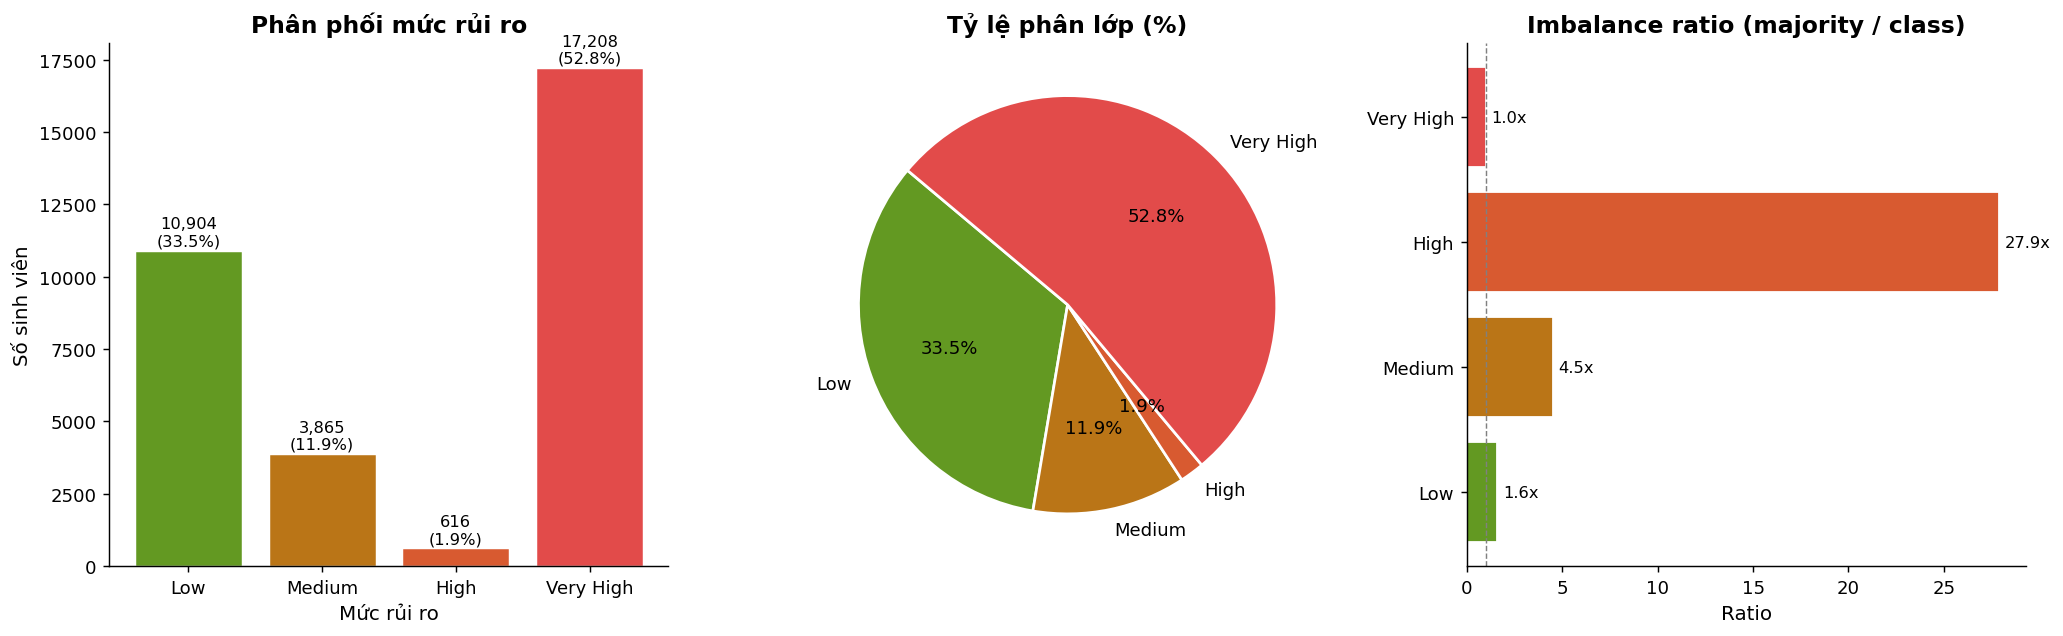


=== Imbalance Summary ===
  Low         : 10,904 ( 33.5%)  ratio=  1.6x  ✅ ĐA SỐ
  Medium      :  3,865 ( 11.9%)  ratio=  4.5x  ⚡ TRUNG BÌNH
  High        :    616 (  1.9%)  ratio= 27.9x  ⚠️ THIỂU SỐ
  Very High   : 17,208 ( 52.8%)  ratio=  1.0x  ✅ ĐA SỐ


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ── 2.1 Bar chart số lượng ────────────────────────────────────────────────────
ax = axes[0]
cnt = df['risk_label'].value_counts().reindex(RISK_ORDER)
bars = ax.bar(RISK_ORDER, cnt.values, color=RISK_PALETTE, edgecolor='white', linewidth=0.8)
ax.set_title('Phân phối mức rủi ro')
ax.set_xlabel('Mức rủi ro'); ax.set_ylabel('Số sinh viên')
for bar, val in zip(bars, cnt.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+80,
            f'{val:,}\n({val/len(df)*100:.1f}%)', ha='center', va='bottom', fontsize=9)

# ── 2.2 Pie chart ─────────────────────────────────────────────────────────────
ax = axes[1]
pct = df['risk_label'].value_counts(normalize=True).reindex(RISK_ORDER)*100
ax.pie(pct.values, labels=RISK_ORDER, colors=RISK_PALETTE,
       autopct='%1.1f%%', startangle=140,
       wedgeprops={'edgecolor':'white','linewidth':1.5})
ax.set_title('Tỷ lệ phân lớp (%)')

# ── 2.3 Imbalance ratio bar ───────────────────────────────────────────────────
ax = axes[2]
max_cnt = cnt.max()
ratios  = (max_cnt / cnt).round(1)
bars2   = ax.barh(RISK_ORDER, ratios.values, color=RISK_PALETTE, edgecolor='white')
ax.set_title('Imbalance ratio (majority / class)')
ax.set_xlabel('Ratio')
ax.axvline(1, color='gray', linestyle='--', linewidth=0.8)
for bar, val in zip(bars2, ratios.values):
    ax.text(val+0.3, bar.get_y()+bar.get_height()/2,
            f'{val:.1f}x', va='center', fontsize=9)

plt.tight_layout()
plt.savefig(VISUALS_DIR+'02_01_imbalance_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n=== Imbalance Summary ===')
for r in RISK_ORDER:
    n = cnt[r]; ratio = max_cnt/n
    status = '⚠️ THIỂU SỐ' if ratio > 5 else ('⚡ TRUNG BÌNH' if ratio > 2 else '✅ ĐA SỐ')
    print(f'  {r:12s}: {n:6,} ({n/len(df)*100:5.1f}%)  ratio={ratio:5.1f}x  {status}')

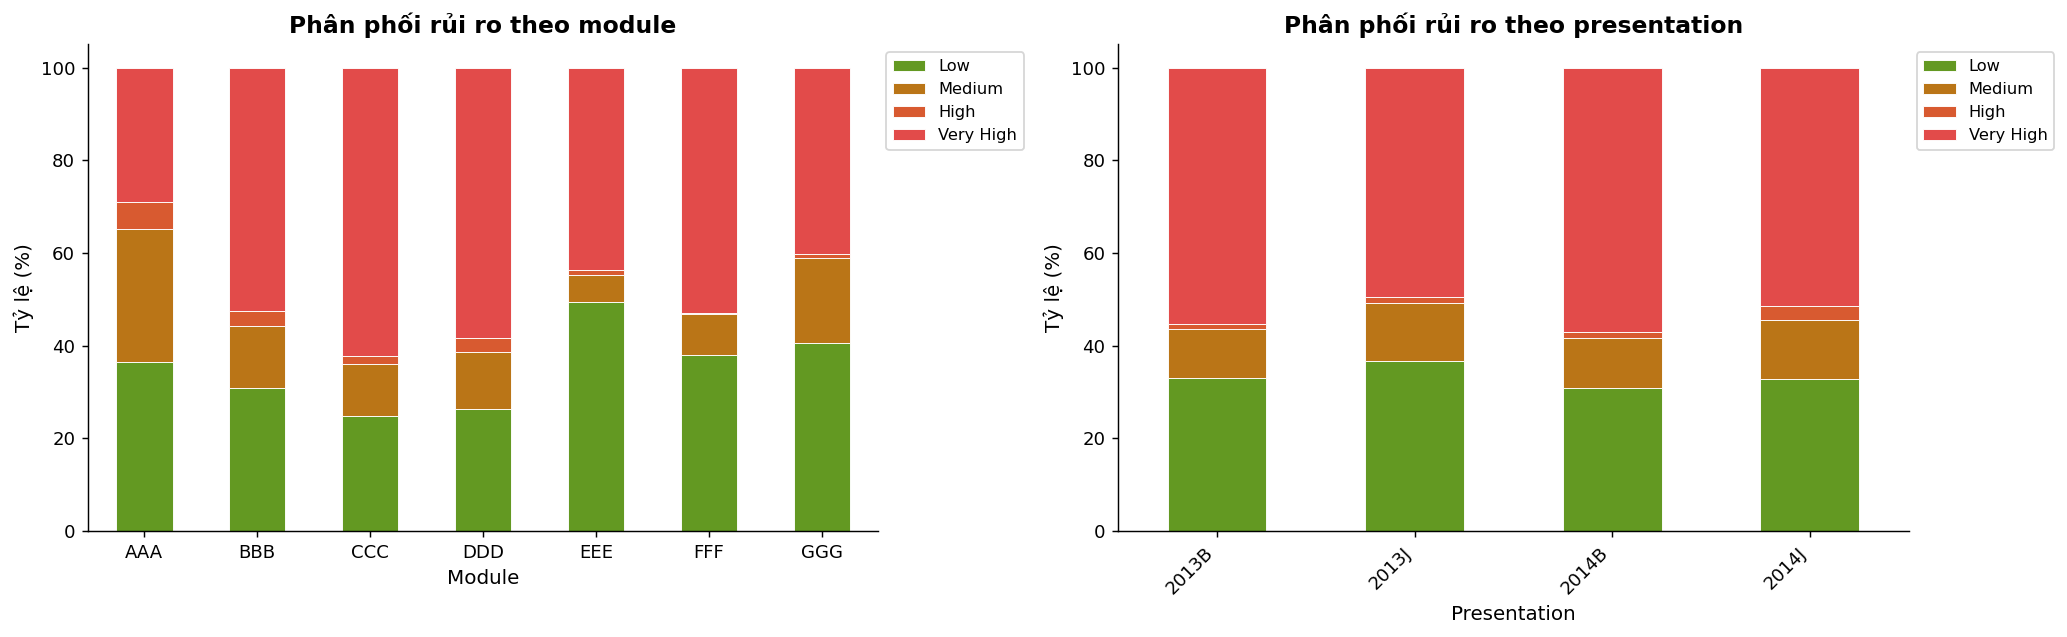

In [4]:
# ── Phân phối theo module và presentation ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Stacked bar theo module
ax = axes[0]
module_risk = df.groupby(['code_module','risk_label']).size().unstack(fill_value=0)
module_risk = module_risk[RISK_ORDER]
module_risk_pct = module_risk.div(module_risk.sum(axis=1), axis=0) * 100
module_risk_pct.plot(kind='bar', stacked=True, ax=ax,
                     color=RISK_PALETTE, edgecolor='white', linewidth=0.5)
ax.set_title('Phân phối rủi ro theo module')
ax.set_xlabel('Module'); ax.set_ylabel('Tỷ lệ (%)')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(RISK_ORDER, bbox_to_anchor=(1,1), fontsize=9)

# Stacked bar theo presentation
ax = axes[1]
pres_risk = df.groupby(['code_presentation','risk_label']).size().unstack(fill_value=0)
pres_risk = pres_risk[[c for c in RISK_ORDER if c in pres_risk.columns]]
pres_risk_pct = pres_risk.div(pres_risk.sum(axis=1), axis=0) * 100
pres_risk_pct.plot(kind='bar', stacked=True, ax=ax,
                   color=RISK_PALETTE, edgecolor='white', linewidth=0.5)
ax.set_title('Phân phối rủi ro theo presentation')
ax.set_xlabel('Presentation'); ax.set_ylabel('Tỷ lệ (%)')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.legend(RISK_ORDER, bbox_to_anchor=(1,1), fontsize=9)

plt.tight_layout()
plt.savefig(VISUALS_DIR+'02_02_risk_by_module_presentation.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 3. Phân Tích Đặc Trưng Nhân Khẩu Học

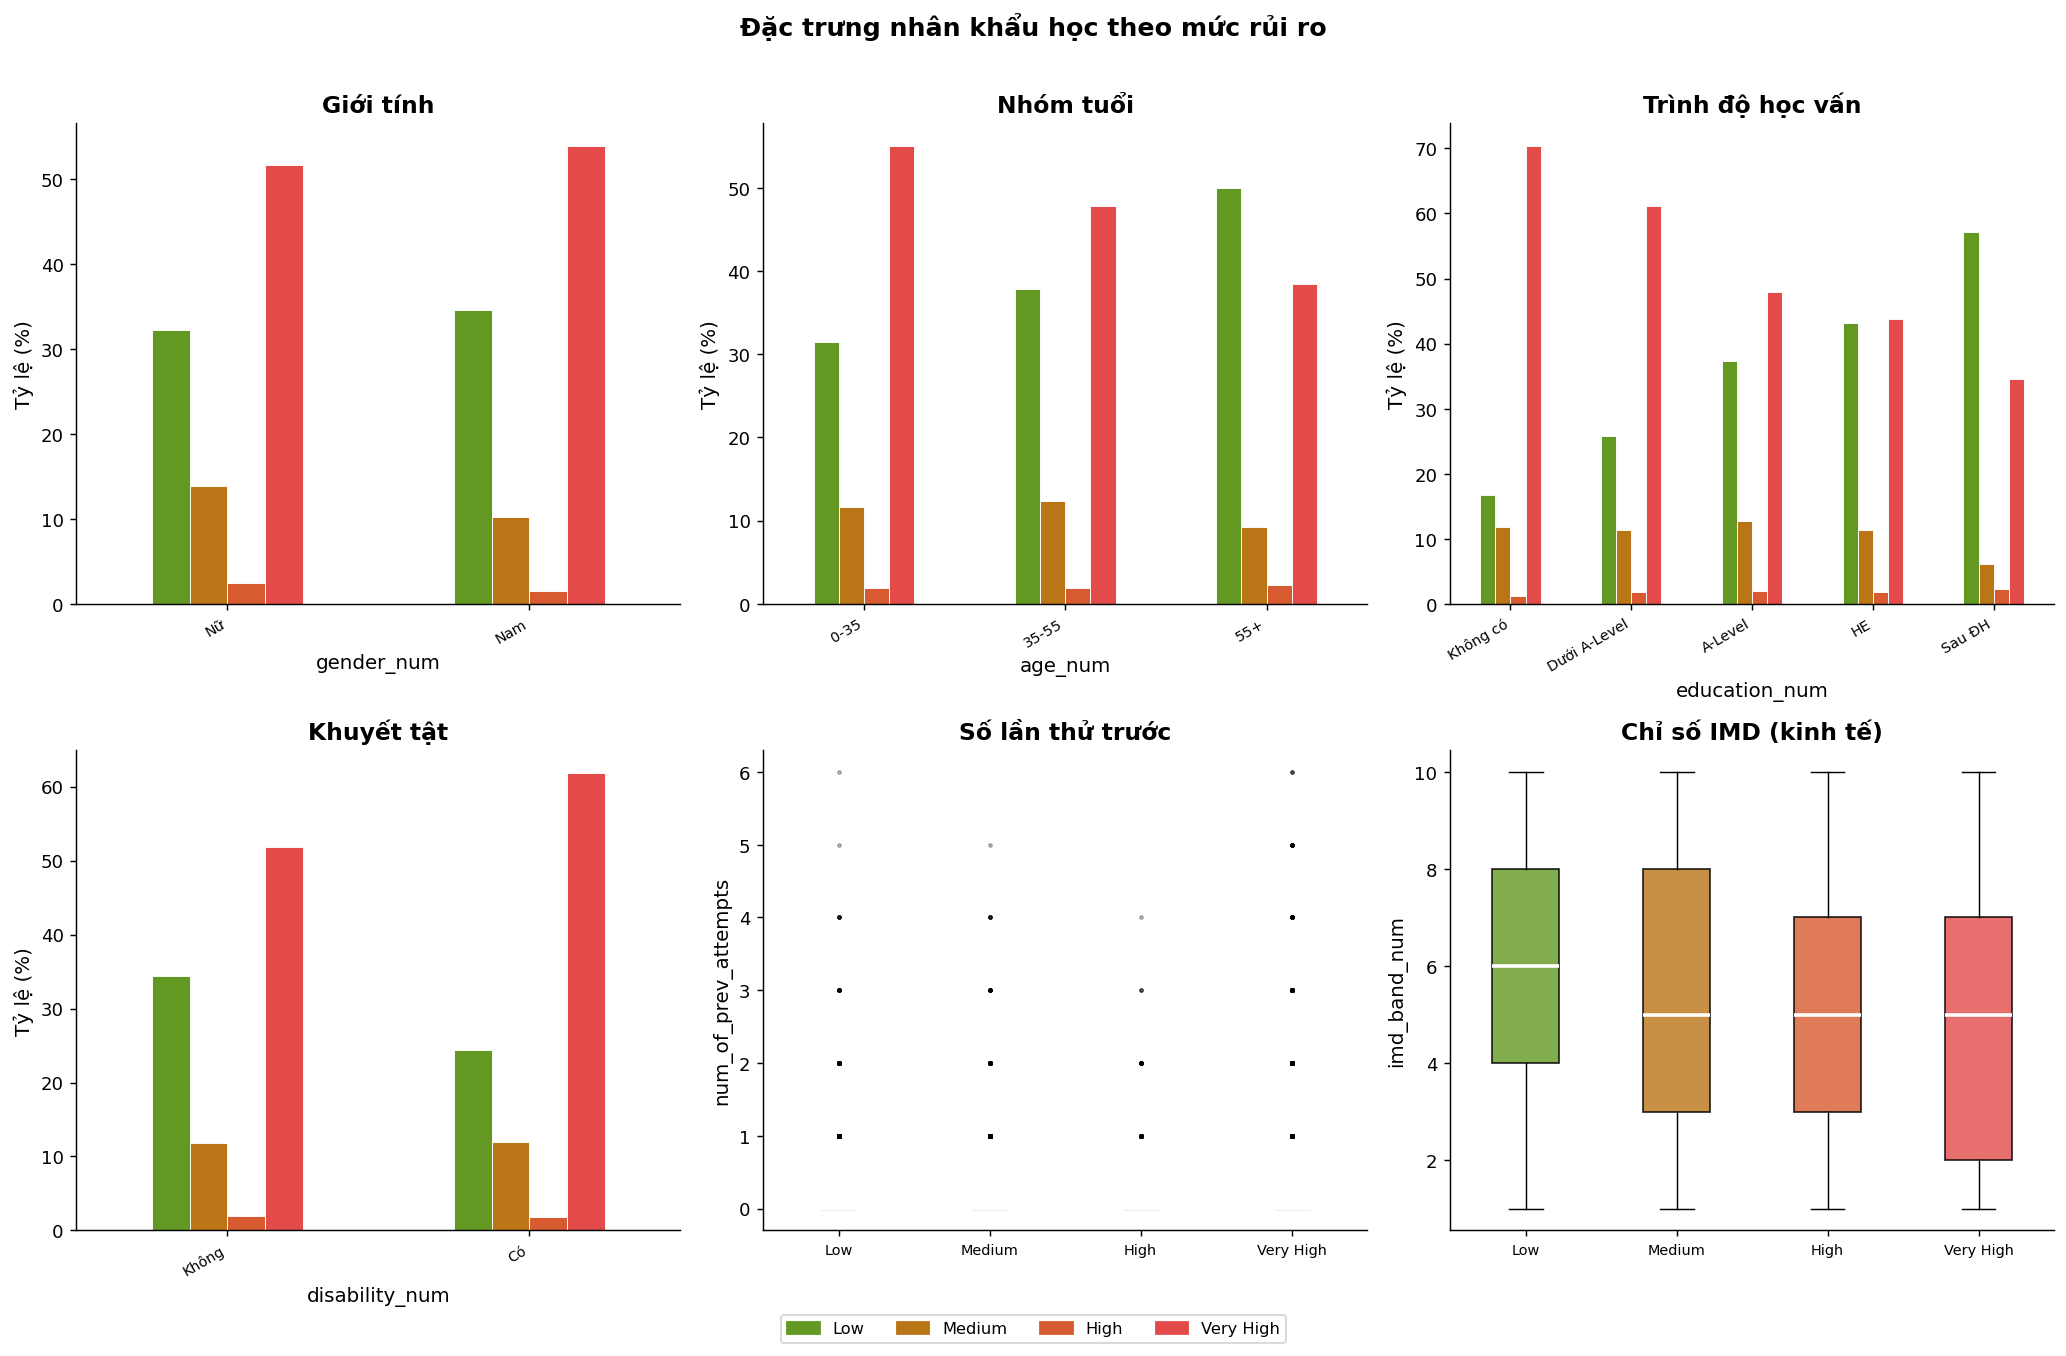

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

demo_features = [
    ('gender_num',          'Giới tính', {0:'Nữ', 1:'Nam'}),
    ('age_num',             'Nhóm tuổi',  {0:'0-35', 1:'35-55', 2:'55+'}),
    ('education_num',       'Trình độ học vấn', {0:'Không có', 1:'Dưới A-Level', 2:'A-Level', 3:'HE', 4:'Sau ĐH'}),
    ('disability_num',      'Khuyết tật', {0:'Không', 1:'Có'}),
    ('num_of_prev_attempts','Số lần thử trước', None),
    ('imd_band_num',        'Chỉ số IMD (kinh tế)', None),
]

for ax, (col, title, mapping) in zip(axes.flat, demo_features):
    if mapping and df[col].nunique() <= 5:
        # Grouped bar cho biến phân loại
        plot_df = df.groupby([col, 'risk_label']).size().unstack(fill_value=0)
        plot_df = plot_df[[c for c in RISK_ORDER if c in plot_df.columns]]
        plot_df_pct = plot_df.div(plot_df.sum(axis=1), axis=0) * 100
        plot_df_pct.plot(kind='bar', ax=ax, color=RISK_PALETTE,
                         edgecolor='white', linewidth=0.5, legend=False)
        ax.set_xticklabels([mapping.get(int(x.get_text()), x.get_text())
                            for x in ax.get_xticklabels()], rotation=30, ha='right', fontsize=8)
        ax.set_ylabel('Tỷ lệ (%)')
    else:
        # Boxplot cho biến liên tục
        data_by_risk = [df[df['risk_label']==r][col].dropna() for r in RISK_ORDER]
        bp = ax.boxplot(data_by_risk, patch_artist=True,
                        medianprops=dict(color='white', linewidth=2),
                        whiskerprops=dict(linewidth=0.8),
                        capprops=dict(linewidth=0.8),
                        flierprops=dict(marker='.', markersize=3, alpha=0.4))
        for patch, color in zip(bp['boxes'], RISK_PALETTE):
            patch.set_facecolor(color); patch.set_alpha(0.8)
        ax.set_xticklabels(RISK_ORDER, fontsize=8)
        ax.set_ylabel(col)
    ax.set_title(title)

handles = [plt.Rectangle((0,0),1,1, color=c) for c in RISK_PALETTE]
fig.legend(handles, RISK_ORDER, loc='lower center', ncol=4, fontsize=9,
           bbox_to_anchor=(0.5,-0.02))
plt.suptitle('Đặc trưng nhân khẩu học theo mức rủi ro', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(VISUALS_DIR+'02_03_demographic_features.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 4. Phân Tích Hành Vi VLE

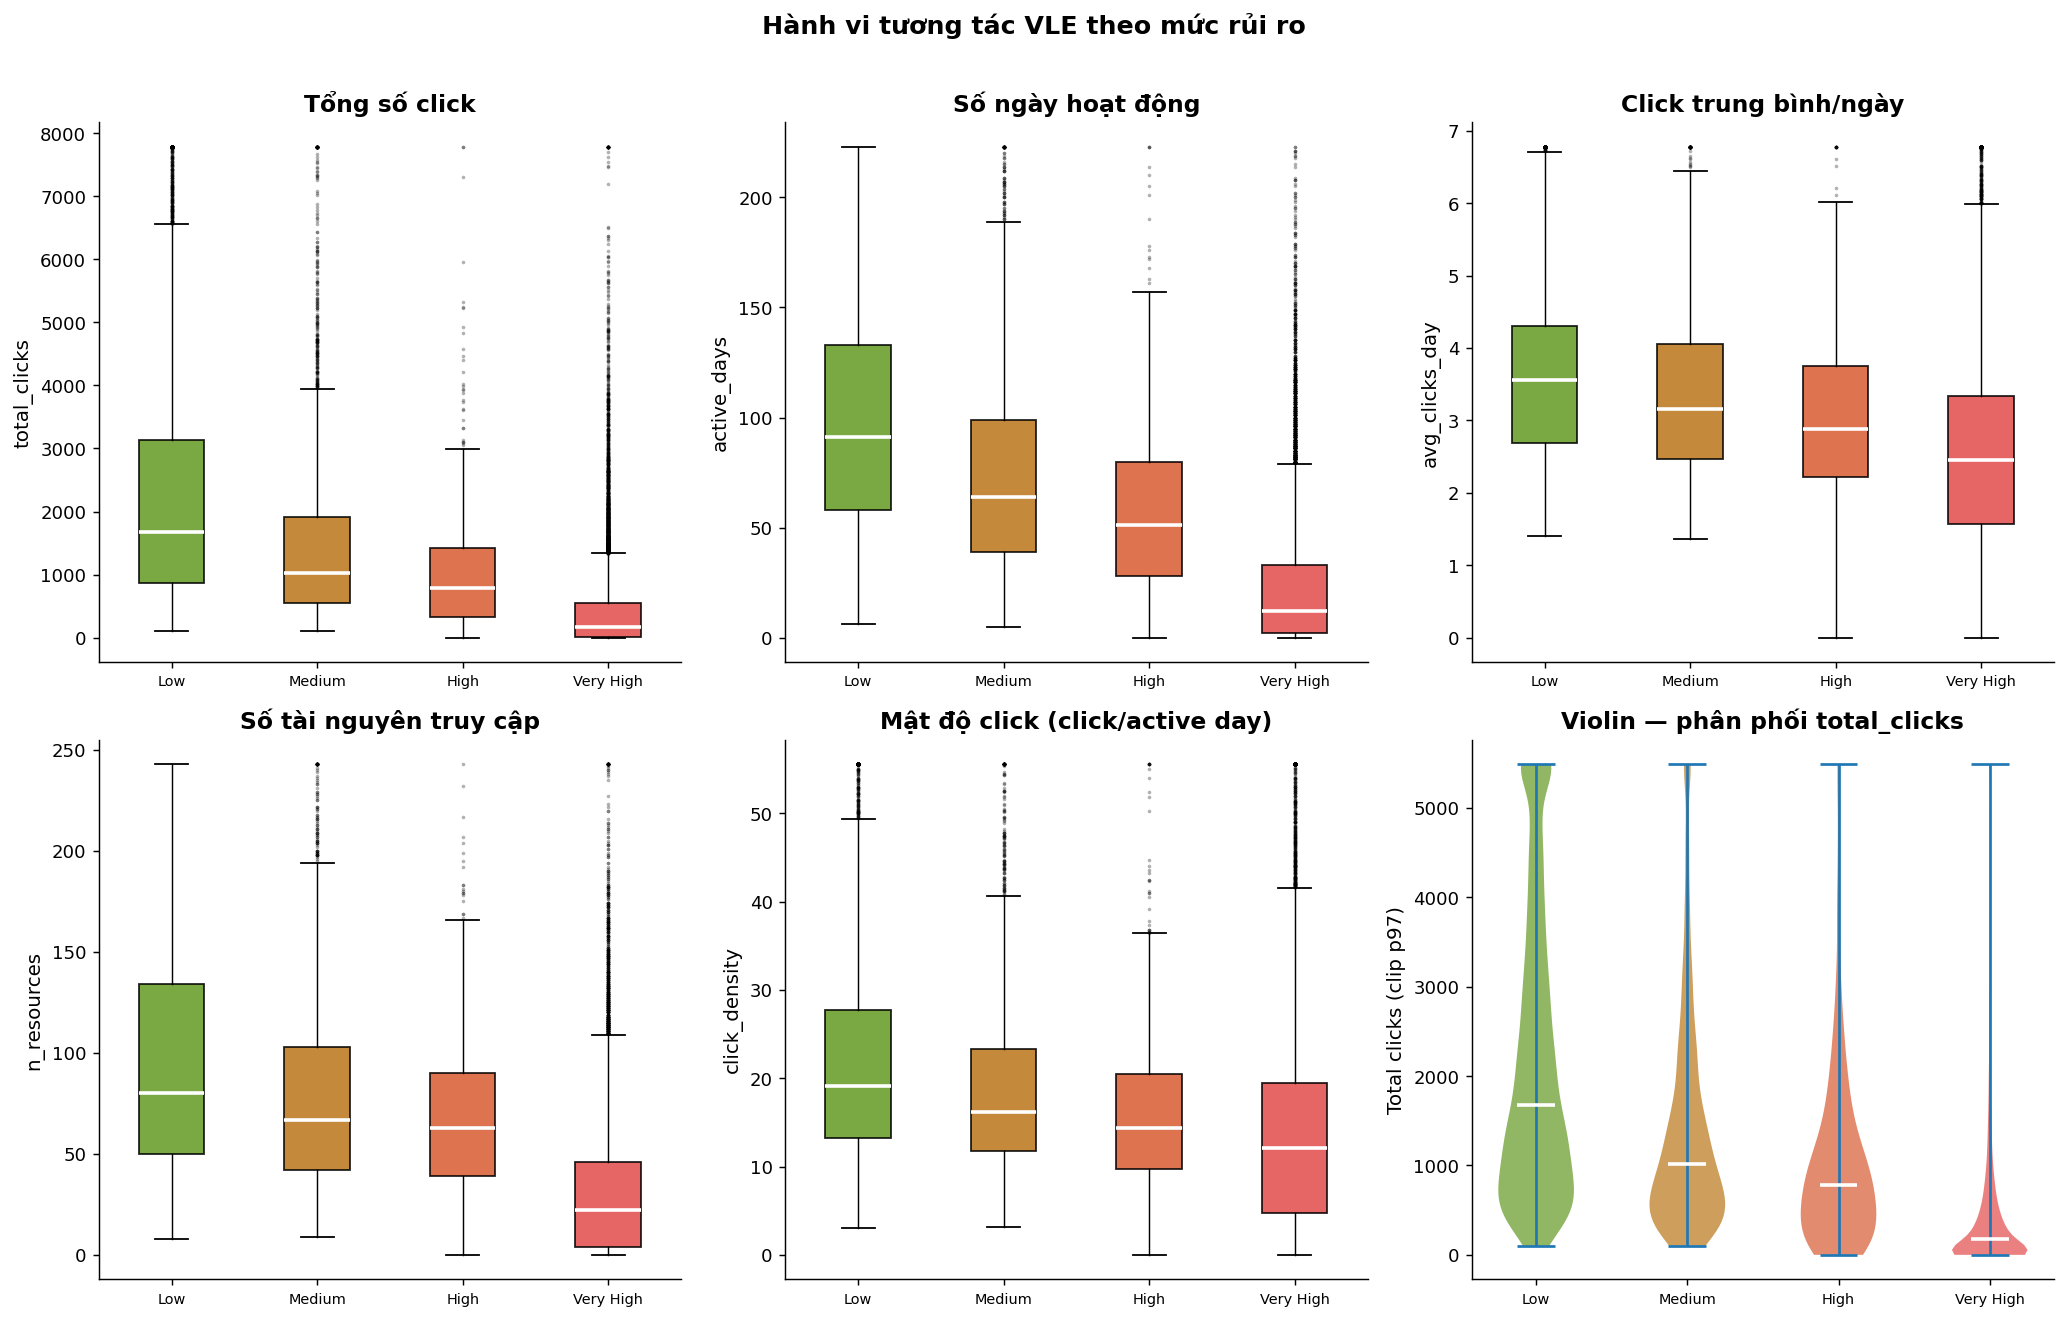


=== Thống kê VLE theo mức rủi ro (median) ===
            total_clicks  active_days  avg_clicks_day  n_resources  click_density
risk_label                                                                       
Low             1673.000       91.000           3.600       80.000         19.100
Medium          1021.000       64.000           3.200       67.000         16.200
High             782.500       51.000           2.900       63.000         14.400
Very High        175.000       12.000           2.500       22.000         12.100


In [6]:
vle_cols = ['total_clicks','active_days','avg_clicks_day','n_resources','click_density']
vle_titles = ['Tổng số click','Số ngày hoạt động','Click trung bình/ngày',
               'Số tài nguyên truy cập','Mật độ click (click/active day)']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

for ax, col, title in zip(axes.flat, vle_cols, vle_titles):
    data_list = [df[df['risk_label']==r][col].clip(upper=df[col].quantile(0.99)) for r in RISK_ORDER]
    bp = ax.boxplot(data_list, patch_artist=True,
                    medianprops=dict(color='white', linewidth=2),
                    whiskerprops=dict(linewidth=0.8),
                    flierprops=dict(marker='.', markersize=2, alpha=0.3))
    for patch, color in zip(bp['boxes'], RISK_PALETTE):
        patch.set_facecolor(color); patch.set_alpha(0.85)
    ax.set_title(title); ax.set_xticklabels(RISK_ORDER, fontsize=8)
    ax.set_ylabel(col)

# Violin plot tổng click (biểu đồ thứ 6)
ax = axes[1][2]
parts = ax.violinplot(
    [df[df['risk_label']==r]['total_clicks'].clip(upper=df['total_clicks'].quantile(0.97)) for r in RISK_ORDER],
    positions=range(4), showmedians=True
)
for pc, color in zip(parts['bodies'], RISK_PALETTE):
    pc.set_facecolor(color); pc.set_alpha(0.7)
parts['cmedians'].set_color('white'); parts['cmedians'].set_linewidth(2)
ax.set_xticks(range(4)); ax.set_xticklabels(RISK_ORDER, fontsize=8)
ax.set_title('Violin — phân phối total_clicks')
ax.set_ylabel('Total clicks (clip p97)')

plt.suptitle('Hành vi tương tác VLE theo mức rủi ro', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(VISUALS_DIR+'02_04_vle_features.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n=== Thống kê VLE theo mức rủi ro (median) ===')
print(df.groupby('risk_label')[vle_cols].median().reindex(RISK_ORDER).round(1).to_string())

---
## 5. Phân Tích Kết Quả Assessment

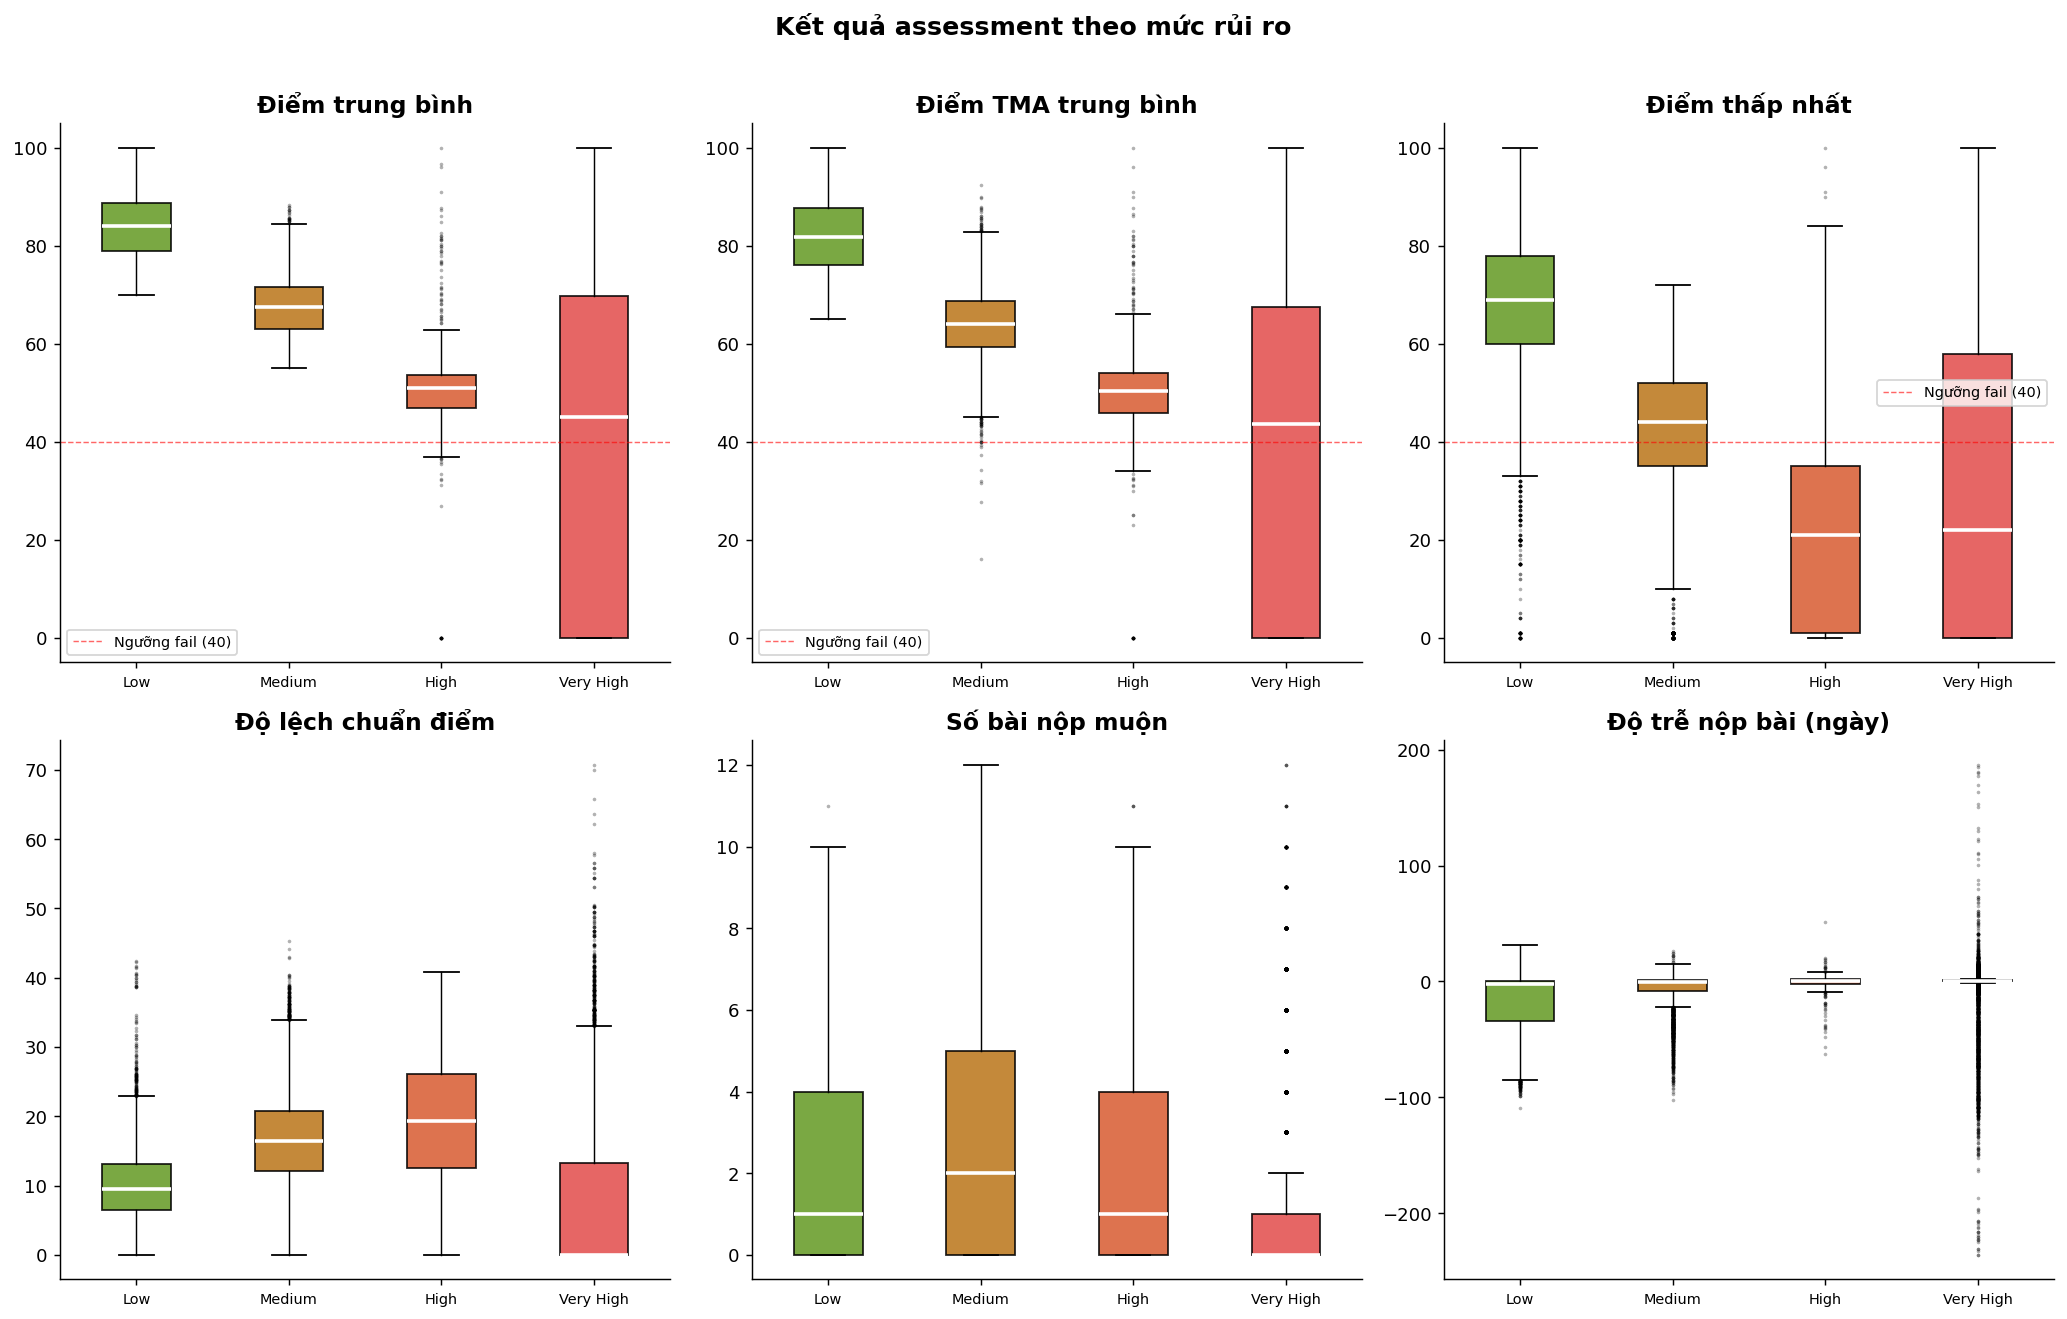


=== Thống kê Assessment theo mức rủi ro (median) ===
            avg_score  avg_tma_score  min_score  std_score  n_late  avg_submit_delay
risk_label                                                                          
Low            84.000         81.830     69.000      9.430   1.000            -2.000
Medium         67.600         64.000     44.000     16.480   2.000            -0.500
High           51.000         50.400     21.000     19.280   1.000             0.000
Very High      45.000         43.600     22.000      0.000   0.000             0.000


In [7]:
asmt_cols   = ['avg_score','avg_tma_score','min_score','std_score','n_late','avg_submit_delay']
asmt_titles = ['Điểm trung bình','Điểm TMA trung bình','Điểm thấp nhất',
                'Độ lệch chuẩn điểm','Số bài nộp muộn','Độ trễ nộp bài (ngày)']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

for ax, col, title in zip(axes.flat, asmt_cols, asmt_titles):
    data_list = [df[df['risk_label']==r][col].dropna() for r in RISK_ORDER]
    bp = ax.boxplot(data_list, patch_artist=True,
                    medianprops=dict(color='white', linewidth=2),
                    whiskerprops=dict(linewidth=0.8),
                    flierprops=dict(marker='.', markersize=2, alpha=0.3))
    for patch, color in zip(bp['boxes'], RISK_PALETTE):
        patch.set_facecolor(color); patch.set_alpha(0.85)
    ax.set_title(title); ax.set_xticklabels(RISK_ORDER, fontsize=8)
    # Thêm đường ngưỡng fail (score < 40)
    if col in ['avg_score','avg_tma_score','min_score']:
        ax.axhline(40, color='red', linestyle='--', linewidth=0.8, alpha=0.6, label='Ngưỡng fail (40)')
        ax.legend(fontsize=8)

plt.suptitle('Kết quả assessment theo mức rủi ro', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(VISUALS_DIR+'02_05_assessment_features.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n=== Thống kê Assessment theo mức rủi ro (median) ===')
print(df.groupby('risk_label')[asmt_cols].median().reindex(RISK_ORDER).round(2).to_string())

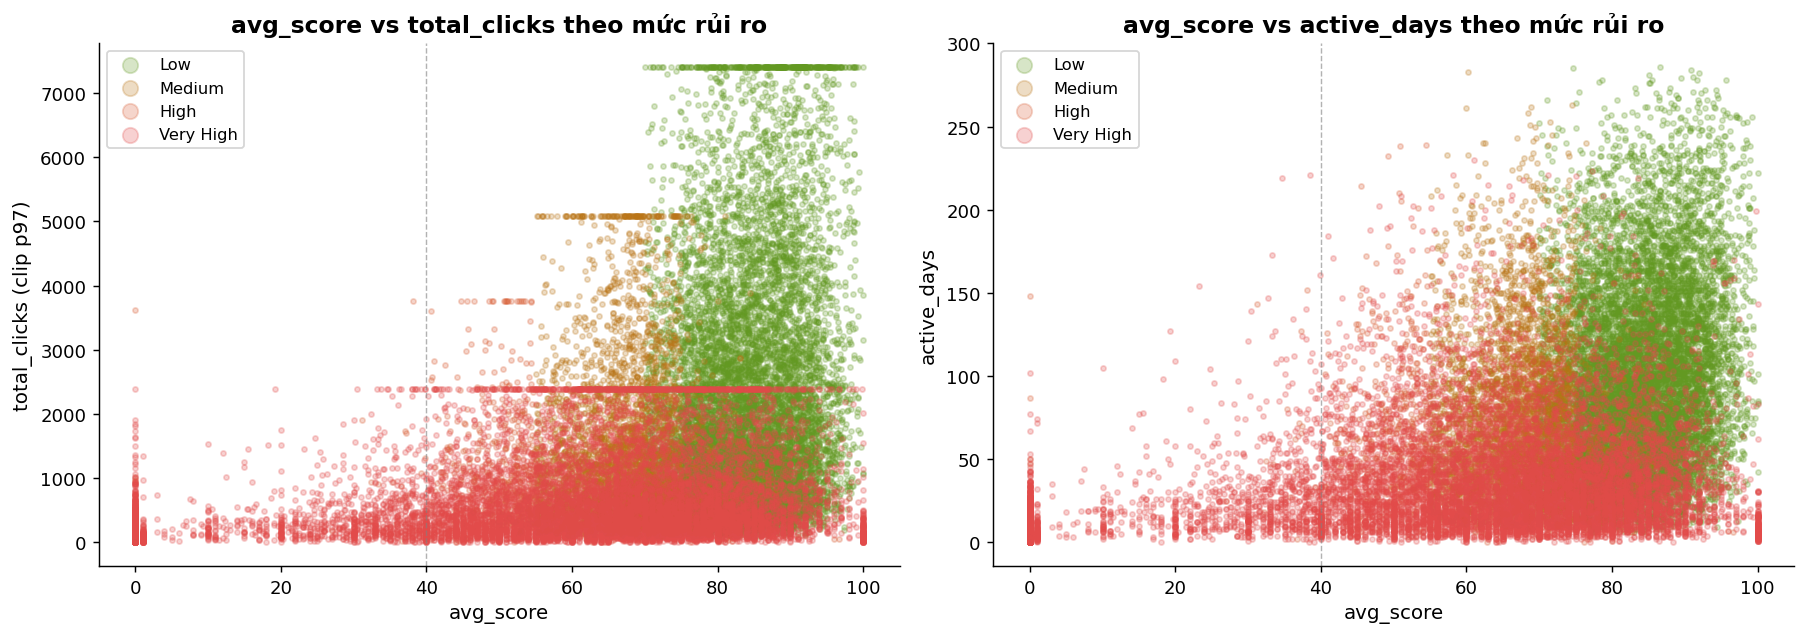

In [8]:
# ── Scatter: avg_score vs total_clicks — colored by risk ─────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
for risk, color in RISK_COLORS.items():
    sub = df[df['risk_label'] == risk]
    ax.scatter(sub['avg_score'],
               sub['total_clicks'].clip(upper=sub['total_clicks'].quantile(0.97)),
               c=color, alpha=0.25, s=8, label=risk)
ax.set_xlabel('avg_score')
ax.set_ylabel('total_clicks (clip p97)')
ax.set_title('avg_score vs total_clicks theo mức rủi ro')
ax.axvline(40, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
ax.legend(markerscale=3, fontsize=9)

ax = axes[1]
for risk, color in RISK_COLORS.items():
    sub = df[df['risk_label'] == risk]
    ax.scatter(sub['avg_score'], sub['active_days'],
               c=color, alpha=0.25, s=8, label=risk)
ax.set_xlabel('avg_score')
ax.set_ylabel('active_days')
ax.set_title('avg_score vs active_days theo mức rủi ro')
ax.axvline(40, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
ax.legend(markerscale=3, fontsize=9)

plt.tight_layout()
plt.savefig(VISUALS_DIR+'02_06_scatter_score_vle.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Ma Trận Tương Quan

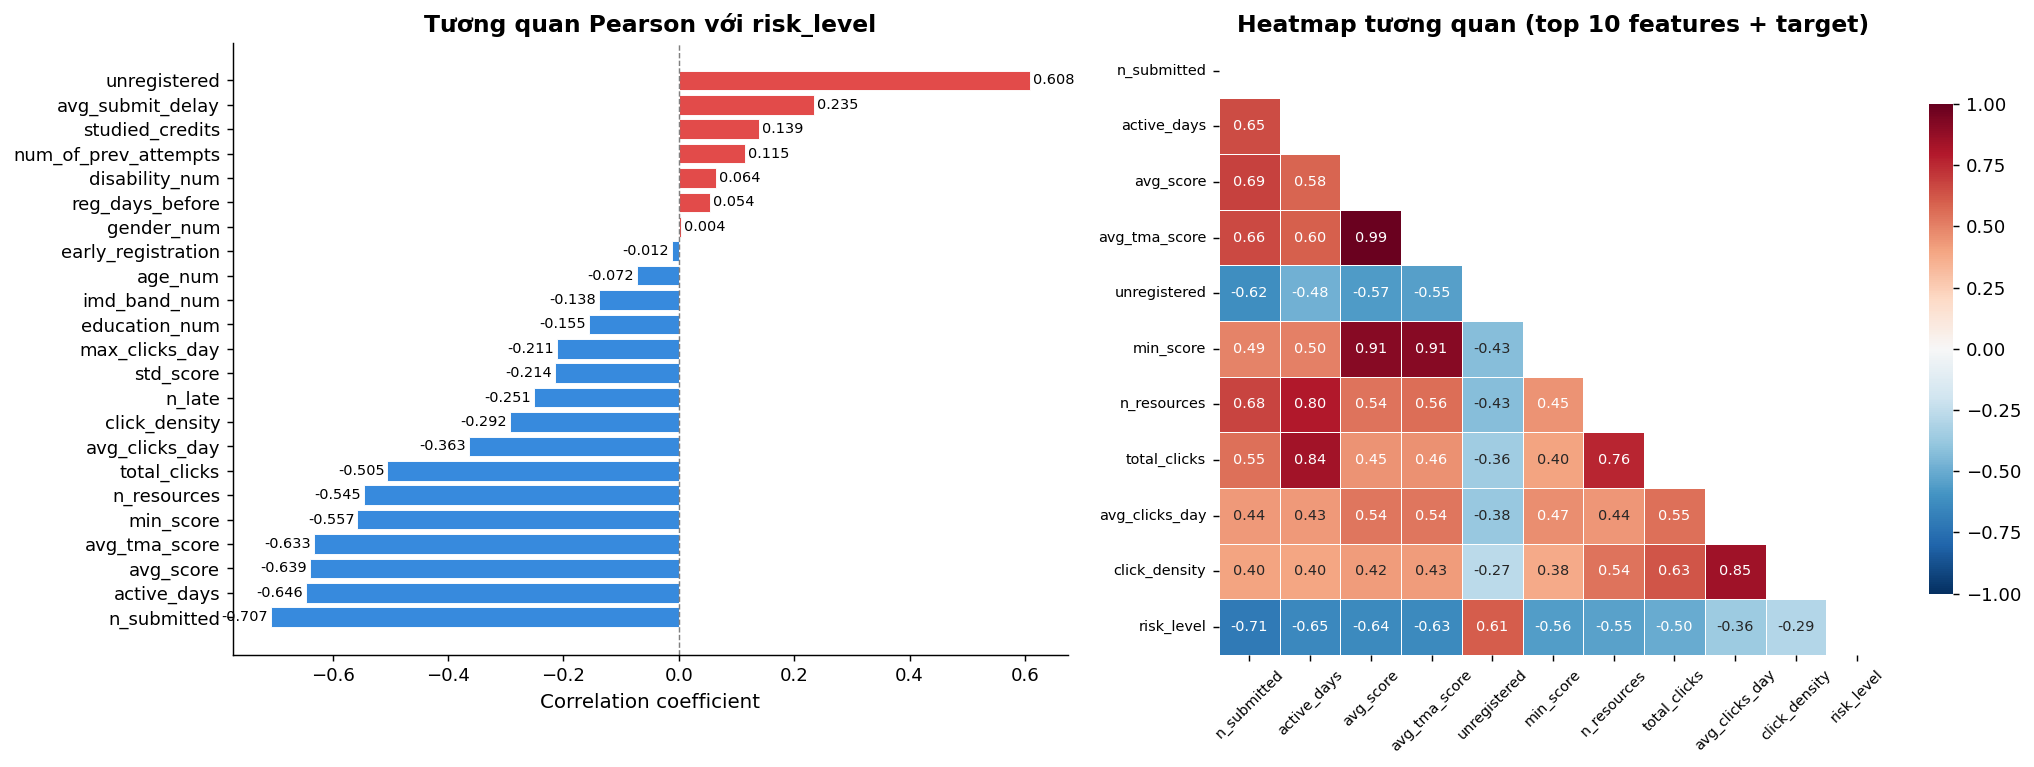


=== Top 5 feature tương quan dương với risk (rủi ro càng cao càng nguy hiểm) ===
disability_num         0.064
num_of_prev_attempts   0.115
studied_credits        0.139
avg_submit_delay       0.235
unregistered           0.608

=== Top 5 feature tương quan âm (càng cao càng an toàn) ===
n_submitted     -0.707
active_days     -0.646
avg_score       -0.639
avg_tma_score   -0.633
min_score       -0.557


In [9]:
# ── Tương quan với risk_level ──────────────────────────────────────────────────
corr_with_target = (
    df[FEATURE_COLS + ['risk_level']]
    .corr()['risk_level']
    .drop('risk_level')
    .sort_values()
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart tương quan với target
ax = axes[0]
colors_bar = ['#E24B4A' if x > 0 else '#378ADD' for x in corr_with_target]
bars = ax.barh(corr_with_target.index, corr_with_target.values,
               color=colors_bar, edgecolor='white', linewidth=0.5)
ax.axvline(0, color='gray', linestyle='--', linewidth=0.8)
ax.set_title('Tương quan Pearson với risk_level')
ax.set_xlabel('Correlation coefficient')
for bar, val in zip(bars, corr_with_target.values):
    ax.text(val + (0.005 if val >= 0 else -0.005),
            bar.get_y()+bar.get_height()/2,
            f'{val:.3f}', va='center', ha='left' if val>=0 else 'right', fontsize=8)

# Heatmap ma trận tương quan đầy đủ
ax = axes[1]
top_features = corr_with_target.abs().nlargest(10).index.tolist() + ['risk_level']
corr_matrix  = df[top_features].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, ax=ax, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            linewidths=0.5, annot_kws={'size':8},
            cbar_kws={'shrink':0.8})
ax.set_title('Heatmap tương quan (top 10 features + target)')
ax.tick_params(axis='x', rotation=45, labelsize=8)
ax.tick_params(axis='y', rotation=0, labelsize=8)

plt.tight_layout()
plt.savefig(VISUALS_DIR+'02_07_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n=== Top 5 feature tương quan dương với risk (rủi ro càng cao càng nguy hiểm) ===')
print(corr_with_target.tail(5).to_string())
print('\n=== Top 5 feature tương quan âm (càng cao càng an toàn) ===')
print(corr_with_target.head(5).to_string())

---
## 7. Phát Hiện Outlier

In [10]:
# ── IQR-based outlier detection ───────────────────────────────────────────────
def count_outliers_iqr(series):
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    n_out = ((series < lower) | (series > upper)).sum()
    return n_out, lower, upper

print('=== Outlier Detection (IQR method) ===')
print(f'{"Feature":<25} {"N outliers":>12} {"% outliers":>12} {"Lower":>10} {"Upper":>10}')
print('-'*75)
outlier_summary = {}
for col in FEATURE_COLS:
    n, lo, hi = count_outliers_iqr(df[col].dropna())
    pct = n / len(df) * 100
    outlier_summary[col] = {'n_outliers':n, 'pct':pct, 'lower':lo, 'upper':hi}
    flag = ' ⚠️' if pct > 5 else ''
    print(f'{col:<25} {n:>12,} {pct:>11.1f}% {lo:>10.1f} {hi:>10.1f}{flag}')

=== Outlier Detection (IQR method) ===
Feature                     N outliers   % outliers      Lower      Upper
---------------------------------------------------------------------------
gender_num                           0         0.0%       -1.5        2.5
imd_band_num                         0         0.0%       -4.5       15.5
education_num                      313         1.0%       -0.5        3.5
age_num                              0         0.0%       -1.5        2.5
disability_num                   3,164         9.7%        0.0        0.0 ⚠️
num_of_prev_attempts             4,172        12.8%        0.0        0.0 ⚠️
studied_credits                    350         1.1%      -30.0      210.0
early_registration                 281         0.9%        1.0        1.0
reg_days_before                    332         1.0%      -77.5      206.5
unregistered                         0         0.0%       -1.5        2.5
total_clicks                     2,503         7.7%    -2022.5   

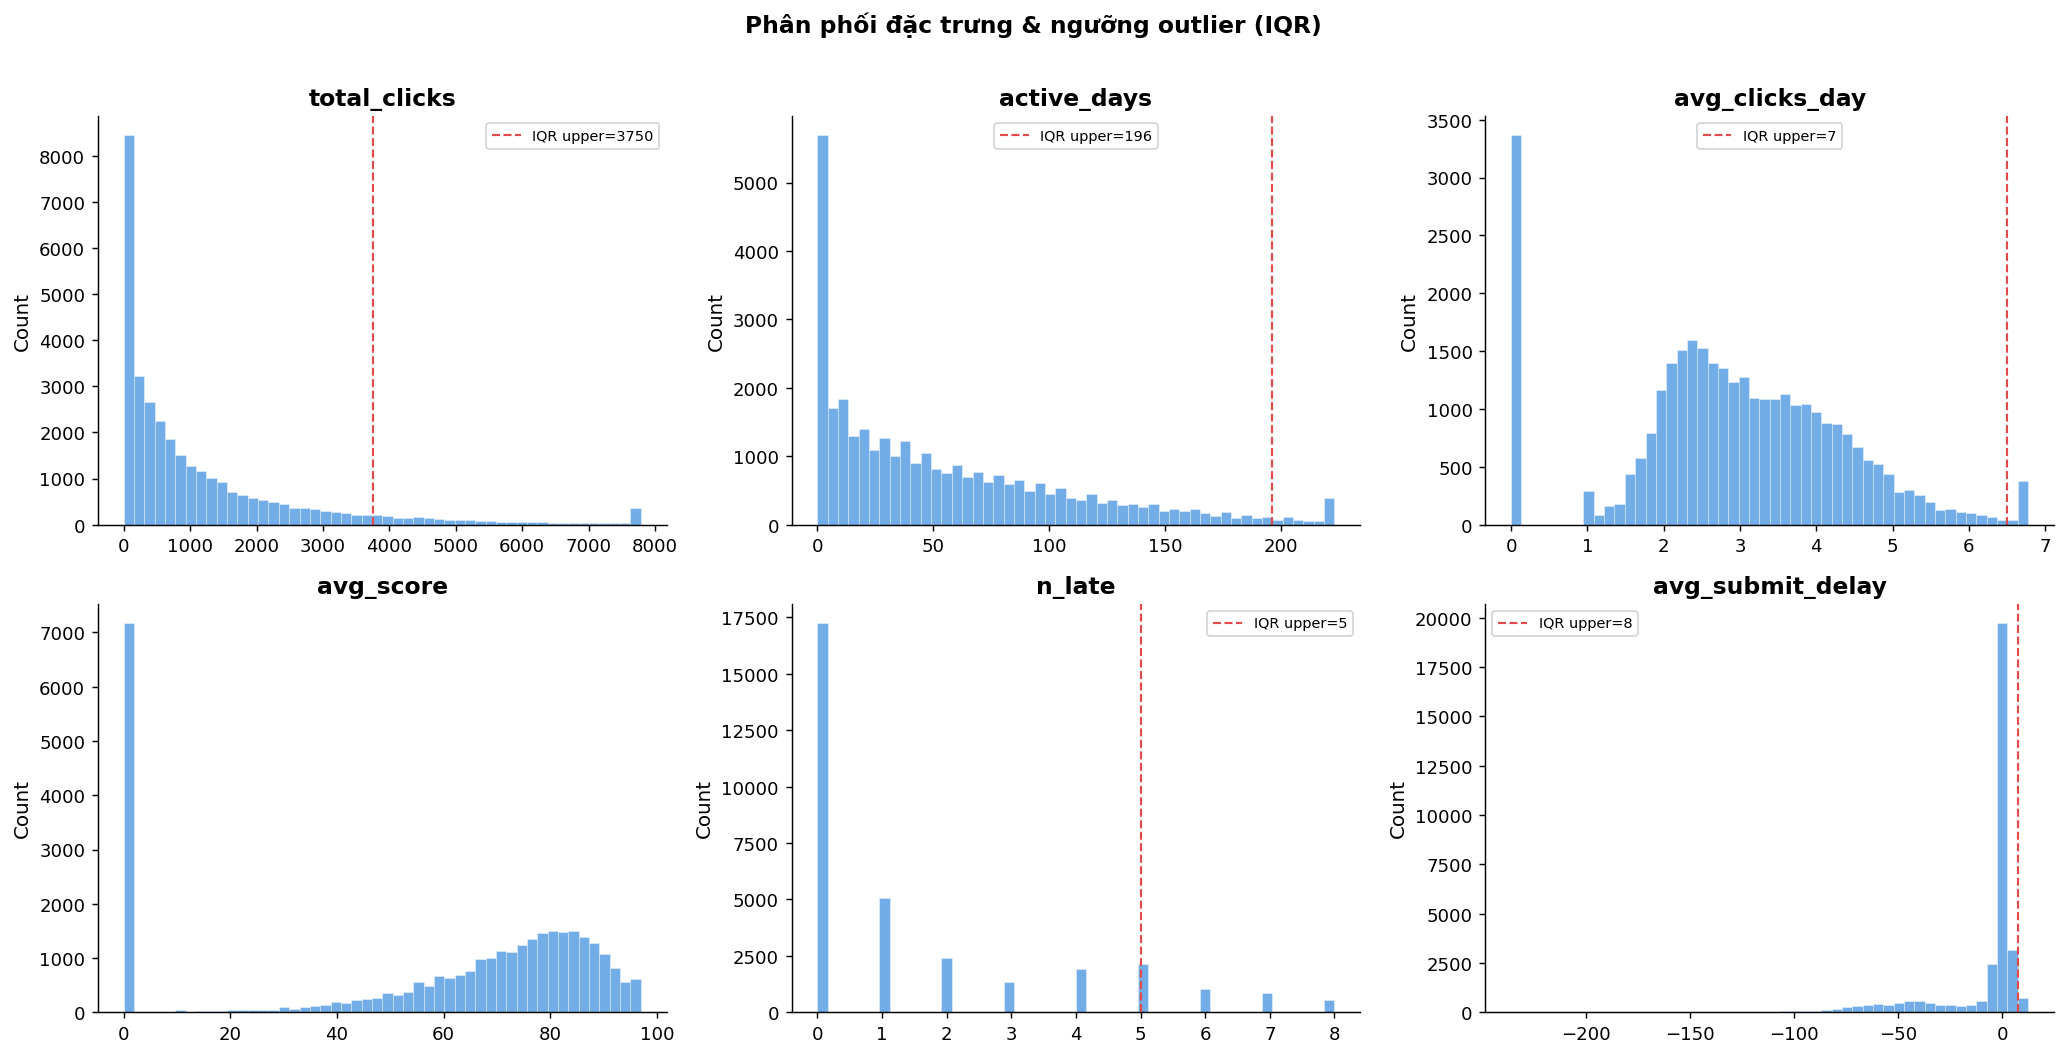


→ Các feature có >5% outlier nên được clip tại p99 trước khi train mô hình


In [11]:
# ── Visualize outlier cho các feature VLE ─────────────────────────────────────
outlier_viz_cols = ['total_clicks','active_days','avg_clicks_day','avg_score','n_late','avg_submit_delay']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.flat, outlier_viz_cols):
    data = df[col].dropna()
    ax.hist(data.clip(upper=data.quantile(0.99)), bins=50,
            color='#378ADD', alpha=0.7, edgecolor='white', linewidth=0.3)
    Q1, Q3 = data.quantile(0.25), data.quantile(0.75)
    IQR = Q3 - Q1
    upper_fence = Q3 + 1.5*IQR
    if upper_fence < data.quantile(0.99):
        ax.axvline(upper_fence, color='#E24B4A', linestyle='--',
                   linewidth=1.2, label=f'IQR upper={upper_fence:.0f}')
        ax.legend(fontsize=8)
    ax.set_title(col); ax.set_ylabel('Count')

plt.suptitle('Phân phối đặc trưng & ngưỡng outlier (IQR)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(VISUALS_DIR+'02_08_outlier_detection.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n→ Các feature có >5% outlier nên được clip tại p99 trước khi train mô hình')

---
## 8. Tổng Kết & Insight

In [12]:
print('=' * 60)
print('TỔNG KẾT EDA — KEY INSIGHTS')
print('=' * 60)

cnt = df['risk_label'].value_counts().reindex(RISK_ORDER)
ratio_high = cnt.max() / cnt['High']

print(f'''
1. IMBALANCE
   - Very High chiếm {cnt["Very High"]/len(df)*100:.1f}% (Fail + Withdrawn thực tế OULAD)
   - Lớp thiểu số nghiêm trọng nhất: High ({cnt["High"]/len(df)*100:.1f}%)
   - Imbalance ratio cao nhất: {ratio_high:.0f}:1 (Very High vs High)
   → Cần xử lý imbalance ở bước preprocessing

2. ĐẶC TRƯNG PHÂN BIỆT MẠNH NHẤT
   - avg_score: tương quan âm mạnh với risk — điểm càng thấp, rủi ro càng cao
   - total_clicks / active_days: sinh viên Very High gần như không tương tác VLE
   - avg_tma_score: chỉ báo sớm tốt cho nhóm Medium và High risk
   - n_late: số bài nộp muộn tăng dần theo mức rủi ro

3. NHÂN KHẨU HỌC
   - imd_band thấp (khu vực nghèo) → tỷ lệ Very High cao hơn
   - Sinh viên có num_of_prev_attempts > 0 → nguy cơ cao hơn đáng kể
   - Nhóm tuổi 55+ có tỷ lệ Withdrawn cao nhất

4. OUTLIER
   - total_clicks và avg_clicks_day có outlier đáng kể (>5%)
   - Cần clip tại p99 hoặc dùng RobustScaler ở bước preprocessing

5. HÀNH ĐỘNG TIẾP THEO (notebook 03)
   - Clip outlier tại p99 cho VLE features
   - Train/val/test split có stratify
   - StandardScaler / RobustScaler
   - SMOTE + class_weight để xử lý imbalance
''')
print('=' * 60)
print('✅ EDA hoàn tất! → Tiếp theo: 03_preprocessing_pipeline.ipynb')

TỔNG KẾT EDA — KEY INSIGHTS

1. IMBALANCE
   - Very High chiếm 52.8% (Fail + Withdrawn thực tế OULAD)
   - Lớp thiểu số nghiêm trọng nhất: High (1.9%)
   - Imbalance ratio cao nhất: 28:1 (Very High vs High)
   → Cần xử lý imbalance ở bước preprocessing

2. ĐẶC TRƯNG PHÂN BIỆT MẠNH NHẤT
   - avg_score: tương quan âm mạnh với risk — điểm càng thấp, rủi ro càng cao
   - total_clicks / active_days: sinh viên Very High gần như không tương tác VLE
   - avg_tma_score: chỉ báo sớm tốt cho nhóm Medium và High risk
   - n_late: số bài nộp muộn tăng dần theo mức rủi ro

3. NHÂN KHẨU HỌC
   - imd_band thấp (khu vực nghèo) → tỷ lệ Very High cao hơn
   - Sinh viên có num_of_prev_attempts > 0 → nguy cơ cao hơn đáng kể
   - Nhóm tuổi 55+ có tỷ lệ Withdrawn cao nhất

4. OUTLIER
   - total_clicks và avg_clicks_day có outlier đáng kể (>5%)
   - Cần clip tại p99 hoặc dùng RobustScaler ở bước preprocessing

5. HÀNH ĐỘNG TIẾP THEO (notebook 03)
   - Clip outlier tại p99 cho VLE features
   - Train/val/test 

In [13]:
# ── Lưu EDA summary ra CSV để tham khảo ──────────────────────────────────────
eda_summary = df.groupby('risk_label')[FEATURE_COLS].agg(['mean','median','std'])
eda_summary.to_csv(PROCESSED_DIR + 'eda_summary_by_risk.csv')
print('✅ Đã lưu: data/processed/eda_summary_by_risk.csv')
print(f'   Biểu đồ: visuals/02_0x_*.png (8 file)')

✅ Đã lưu: data/processed/eda_summary_by_risk.csv
   Biểu đồ: visuals/02_0x_*.png (8 file)
